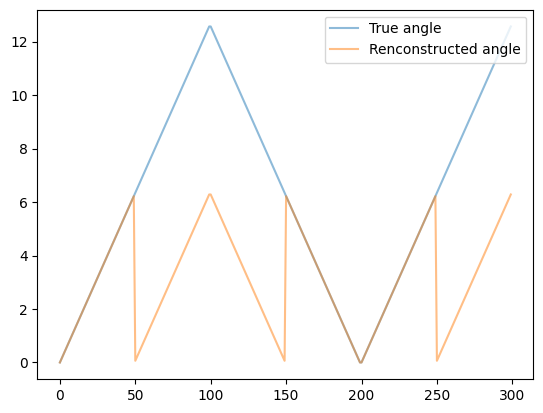

In [57]:

import numpy as np
import matplotlib.pyplot as plt

def get_angles(x,y) -> np.typing.NDArray :
    '''returns the angle of a given pos'''

    theta = np.arctan2(x,y)

    theta %= np.pi*2

    return theta

samples = 300

true_angle = np.hstack((np.linspace(0,np.pi*4,samples//3),np.linspace(0,np.pi*4,samples//3)[::-1],np.linspace(0,np.pi*4,samples//3)))

test_x = np.sin(true_angle)
test_y = np.cos(true_angle)

calc_angle = get_angles(test_x,test_y)


x_axis = range(0,samples)
plt.plot(x_axis,true_angle,label='True angle',alpha=0.5)
plt.plot(x_axis,calc_angle,label='Renconstructed angle',alpha=0.5)
plt.legend()
plt.show()



becouse angles are cyclic we need to deal with when the angle wrapps back round


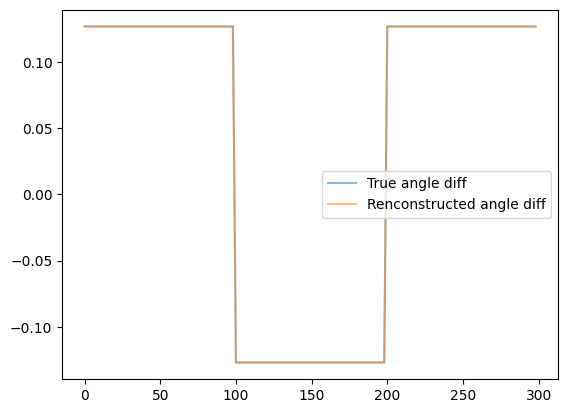

In [68]:

def get_angle_diff(theta) :

    raw_diff = theta[1:] - theta[:-1]

    # find places where the diff is more than 180 degrees 
    # as that means that there was a wrap around 

    mod_diff = raw_diff % np.pi 

    mod_p1_diff = mod_diff - np.pi # incase the diff is in the other direction i.e 179 instead of -1 deg

    diff = np.array([

        v if abs(mod_p1_diff[i]) > v else mod_p1_diff[i]
        for i,v in enumerate(mod_diff)

    ])

    return diff
 
true_angle_diff = true_angle[1:] - true_angle[:-1]
calc_angle_diff = get_angle_diff(calc_angle)

plt.clf()
plt.plot(x_axis[:-1],true_angle_diff,label='True angle diff',alpha=0.5)
plt.plot(x_axis[:-1],calc_angle_diff,label='Renconstructed angle diff',alpha=0.5)
plt.legend()
plt.savefig('plot1.svg')

seems to be able to calculate the rate of angle change accuratly, now to detect when it crosses over the x axis, i.e turns around

0.1269330365086780 0.0000000000000000
0.0000000000000000 -0.1269330365086780
-0.1269330365086785 0.0000000000000000
0.0000000000000000 0.1269330365086785


C:\Users\dan\AppData\Local\Temp\ipykernel_10156\3941947266.py:18: MatplotlibDeprecationWarning: Passing the label parameter of vlines() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  plt.vlines(


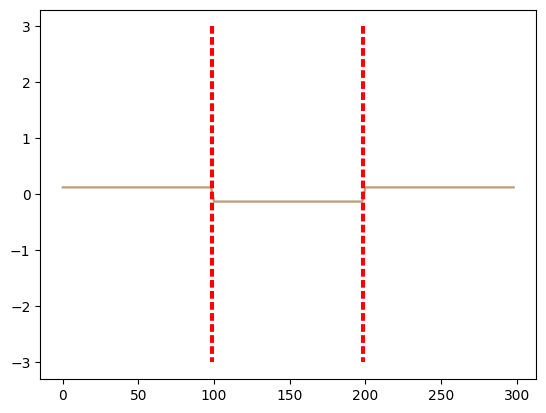

In [80]:

def find_turn_around_points(d_angle) -> list[tuple[int,int]] :
    '''retunrs a list of timestamp pairs, between which turnarounds are detected'''

    turn_arounds = []
    for start in np.where(np.diff(np.sign(d_angle)))[0] :
        turn_arounds.append((start,start+1))

    return turn_arounds

turns = find_turn_around_points(calc_angle_diff)

for start,end in turns :
    print('{0:.16f}'.format(calc_angle_diff[start]),end=' ')
    print('{0:.16f}'.format(calc_angle_diff[end]),end='\n')

plt.plot(x_axis[:-1],true_angle_diff,label='True angle diff',alpha=0.5)
plt.plot(x_axis[:-1],calc_angle_diff,label='Renconstructed angle diff',alpha=0.5)
plt.vlines(
    [start for start,end in find_turn_around_points(calc_angle_diff)],
    3,
    -3,
    'r',
    'dashed',
    'turn arounds'
)

plt.savefig('plot.svg')



Bringing it all together

In [ ]:

def find_turning_points(x,y) -> list[tuple[int,int]] :

    '''
    find turning points in the movements of a fish , 
    given its x and y coords , will return a list of
    timestamps of detections of turnarounds.
    '''

    theta = np.arctan2(x,y)
    theta %= np.pi*2

    raw_diff = theta[1:] - theta[:-1]

    # find places where the diff is more than 180 degrees 
    # as that means that there was a wrap around 

    mod_diff = raw_diff % np.pi 

    mod_p1_diff = mod_diff - np.pi # incase the diff is in the other direction i.e 179 instead of -1 deg

    diff = np.array([

        v if abs(mod_p1_diff[i]) > v else mod_p1_diff[i]
        for i,v in enumerate(mod_diff)

    ])

    turn_arounds = []
    for start in np.where(np.diff(np.sign(diff)))[0] :
        turn_arounds.append((start,start+1))

    return turn_arounds
